# 구글드라이브 연결

In [110]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/data/")
os.listdir(DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['movies.csv', 'ratings.csv', 'tags.csv', 'links.csv']

# 데이터 로드

https://grouplens.org/datasets/movielens/

https://files.grouplens.org/datasets/movielens/ml-10m-README.html

In [111]:
MOVIE_DATA_PATH = f"{DATA_DIR}/movies.csv"
RATING_DATA_PATH = f"{DATA_DIR}/ratings.csv"
TAG_DATA_PATH = f"{DATA_DIR}/tags.csv"

In [112]:
import pandas as pd

movies_df = pd.read_csv(MOVIE_DATA_PATH)
ratings_df = pd.read_csv(RATING_DATA_PATH)
tags_df = pd.read_csv(TAG_DATA_PATH)

In [113]:
movies_df

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [114]:
ratings_df

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [115]:
tags_df

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
...,...,...,...,...
3678,606,7382,for katie,1171234019
3679,606,7936,austere,1173392334
3680,610,3265,gun fu,1493843984
3681,610,3265,heroic bloodshed,1493843978


# 전처리

## 컬럼명 변경

In [116]:
# movies_df = movies_df.rename(columns={'movieId': 'movie_id'}, inplace=True)
movies_df = movies_df.rename(columns={'movieId': 'movie_id'})
ratings_df = ratings_df.rename(columns={'movieId': 'movie_id', 'userId': 'user_id'})
tags_df = tags_df.rename(columns={'movieId': 'movie_id', 'userId': 'user_id'})

In [117]:
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [118]:
ratings_df

,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [119]:
tags_df

,user_id,movie_id,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
...,...,...,...,...
3678,606,7382,for katie,1171234019
3679,606,7936,austere,1173392334
3680,610,3265,gun fu,1493843984
3681,610,3265,heroic bloodshed,1493843978


## ID 형변환

In [120]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  9742 non-null   int64 
 1   title     9742 non-null   object
 2   genres    9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [121]:
movies_df['movie_id'] = movies_df['movie_id'].astype(str)
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  9742 non-null   object
 1   title     9742 non-null   object
 2   genres    9742 non-null   object
dtypes: object(3)
memory usage: 228.5+ KB


In [122]:
ratings_df['user_id'] = ratings_df['user_id'].astype(str)
ratings_df['movie_id'] = ratings_df['movie_id'].astype(str)
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    100836 non-null  object 
 1   movie_id   100836 non-null  object 
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 3.1+ MB


In [123]:
tags_df['user_id'] = tags_df['user_id'].astype(str)
tags_df['movie_id'] = tags_df['movie_id'].astype(str)
tags_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    3683 non-null   object
 1   movie_id   3683 non-null   object
 2   tag        3683 non-null   object
 3   timestamp  3683 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 115.2+ KB


## 중복 처리

### 중복체크

In [124]:
len(movies_df)  # 무비 데이터 수

9742

In [125]:
movies_df['movie_id'].nunique()  # 무비 id 수

9742

In [126]:
movies_df['title'].nunique()  # 무비 제목 != 무비 id 수

9737

In [127]:
# 제목 중복된 영화
movies_df[movies_df.duplicated('title')]

,movie_id,title,genres
5601,26958,Emma (1996),Romance
6932,64997,War of the Worlds (2005),Action|Sci-Fi
9106,144606,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Romance|Thriller
9135,147002,Eros (2004),Drama|Romance
9468,168358,Saturn 3 (1980),Sci-Fi|Thriller


In [128]:
# 중복 개수까지 체크
movies_df['title'].value_counts()[movies_df['title'].value_counts() > 1]

,count
title,
Emma (1996),2
War of the Worlds (2005),2
Eros (2004),2
Confessions of a Dangerous Mind (2002),2
Saturn 3 (1980),2


### 중복값 처리

영화1) Emma

movies 데이터 처리

In [129]:
movie_titile = "Emma (1996)"
movies_df[movies_df['title'] == movie_titile]

,movie_id,title,genres
650,838,Emma (1996),Comedy|Drama|Romance
5601,26958,Emma (1996),Romance


In [130]:
unique_id = movies_df[movies_df['title'] == movie_titile]['movie_id'].values[0]
unique_id

'838'

In [131]:
duplicated_id = movies_df[movies_df['title'] == movie_titile]['movie_id'].values[1]
duplicated_id

'26958'

In [132]:
# 중복 데이터 제거
movies_df = movies_df[~(movies_df['movie_id'] == duplicated_id)].copy()
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


ratings 데이터 처리

In [133]:
ratings_df[ratings_df['movie_id'] == duplicated_id]

,user_id,movie_id,rating,timestamp
80596,509,26958,3.5,1436031753


In [134]:
duplicated_index = ratings_df[ratings_df['movie_id'] == duplicated_id].index
duplicated_index

Index([80596], dtype='int64')

In [135]:
ratings_df.loc[duplicated_index, 'movie_id'] = unique_id

In [136]:
# 검산: 삭제 여부 확인
ratings_df[ratings_df['movie_id'] == duplicated_id]

,user_id,movie_id,rating,timestamp


In [137]:
# 검산: 중복 id 변경 확인
ratings_df.loc[duplicated_index]

,user_id,movie_id,rating,timestamp
80596,509,838,3.5,1436031753


영화2) War of the Worlds

movies 데이터 처리

In [138]:
movie_titile = "War of the Worlds (2005)"
movies_df[movies_df['title'] == movie_titile]

,movie_id,title,genres
5931,34048,War of the Worlds (2005),Action|Adventure|Sci-Fi|Thriller
6932,64997,War of the Worlds (2005),Action|Sci-Fi


In [139]:
unique_id = movies_df[movies_df['title'] == movie_titile]['movie_id'].values[0]
unique_id

'34048'

In [140]:
duplicated_id = movies_df[movies_df['title'] == movie_titile]['movie_id'].values[1]
duplicated_id

'64997'

In [141]:
# 중복 데이터 제거
movies_df = movies_df[~(movies_df['movie_id'] == duplicated_id)].copy()
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


ratings 데이터 처리

In [142]:
ratings_df[ratings_df['movie_id'] == duplicated_id]

,user_id,movie_id,rating,timestamp
4747,28,64997,3.5,1234850075
11451,68,64997,2.5,1230497715


In [143]:
duplicated_index = ratings_df[ratings_df['movie_id'] == duplicated_id].index
duplicated_index

Index([4747, 11451], dtype='int64')

In [144]:
ratings_df.loc[duplicated_index, 'movie_id'] = unique_id

In [145]:
# 검산: 삭제 여부 확인
ratings_df[ratings_df['movie_id'] == duplicated_id]

,user_id,movie_id,rating,timestamp


In [146]:
# 검산: 중복 id 변경 확인
ratings_df.loc[duplicated_index]

,user_id,movie_id,rating,timestamp
4747,28,34048,3.5,1234850075
11451,68,34048,2.5,1230497715


영화3) Confessions of a Dangerous Mind

movies 데이터 처리

In [147]:
movie_titile = "Confessions of a Dangerous Mind (2002)"
movies_df[movies_df['title'] == movie_titile]

,movie_id,title,genres
4169,6003,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Thriller
9106,144606,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Romance|Thriller


In [148]:
unique_id = movies_df[movies_df['title'] == movie_titile]['movie_id'].values[0]
duplicated_id = movies_df[movies_df['title'] == movie_titile]['movie_id'].values[1]

In [149]:
# 중복 데이터 제거
movies_df = movies_df[~(movies_df['movie_id'] == duplicated_id)].copy()
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


ratings 데이터 처리

In [150]:
ratings_df[ratings_df['movie_id'] == duplicated_id]

,user_id,movie_id,rating,timestamp
17819,111,144606,4.0,1517441257


In [151]:
duplicated_index = ratings_df[ratings_df['movie_id'] == duplicated_id].index
duplicated_index

Index([17819], dtype='int64')

In [152]:
ratings_df.loc[duplicated_index, 'movie_id'] = unique_id

In [153]:
# 검산: 삭제 여부 확인
ratings_df[ratings_df['movie_id'] == duplicated_id]

,user_id,movie_id,rating,timestamp


In [154]:
# 검산: 중복 id 변경 확인
ratings_df.loc[duplicated_index]

,user_id,movie_id,rating,timestamp
17819,111,6003,4.0,1517441257


영화4) Eros

movies 데이터 처리

In [155]:
movie_titile = "Eros (2004)"
movies_df[movies_df['title'] == movie_titile]

,movie_id,title,genres
5854,32600,Eros (2004),Drama
9135,147002,Eros (2004),Drama|Romance


In [156]:
unique_id = movies_df[movies_df['title'] == movie_titile]['movie_id'].values[0]
duplicated_id = movies_df[movies_df['title'] == movie_titile]['movie_id'].values[1]

In [157]:
# 중복 데이터 제거
movies_df = movies_df[~(movies_df['movie_id'] == duplicated_id)].copy()
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


ratings 데이터 처리

In [158]:
ratings_df[ratings_df['movie_id'] == duplicated_id]

,user_id,movie_id,rating,timestamp
49832,318,147002,4.0,1502207152


In [159]:
duplicated_index = ratings_df[ratings_df['movie_id'] == duplicated_id].index
duplicated_index

Index([49832], dtype='int64')

In [160]:
ratings_df.loc[duplicated_index, 'movie_id'] = unique_id

In [161]:
# 검산: 삭제 여부 확인
ratings_df[ratings_df['movie_id'] == duplicated_id]

,user_id,movie_id,rating,timestamp


In [162]:
# 검산: 중복 id 변경 확인
ratings_df.loc[duplicated_index]

,user_id,movie_id,rating,timestamp
49832,318,32600,4.0,1502207152


영화5) Saturn 3

movie 데이터 처리

In [163]:
movie_titile = "Saturn 3 (1980)"
movies_df[movies_df['title'] == movie_titile]

,movie_id,title,genres
2141,2851,Saturn 3 (1980),Adventure|Sci-Fi|Thriller
9468,168358,Saturn 3 (1980),Sci-Fi|Thriller


In [164]:
unique_id = movies_df[movies_df['title'] == movie_titile]['movie_id'].values[0]
duplicated_id = movies_df[movies_df['title'] == movie_titile]['movie_id'].values[1]

In [165]:
# 중복 데이터 제거
movies_df = movies_df[~(movies_df['movie_id'] == duplicated_id)].copy()
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


ratings 데이터 처리

In [166]:
ratings_df[ratings_df['movie_id'] == duplicated_id]

,user_id,movie_id,rating,timestamp
81458,514,168358,2.5,1533945970


In [167]:
duplicated_index = ratings_df[ratings_df['movie_id'] == duplicated_id].index
duplicated_index

Index([81458], dtype='int64')

In [168]:
ratings_df.loc[duplicated_index, 'movie_id'] = unique_id

In [169]:
# 검산: 삭제 여부 확인
ratings_df[ratings_df['movie_id'] == duplicated_id]

,user_id,movie_id,rating,timestamp


In [170]:
# 검산: 중복 id 변경 확인
ratings_df.loc[duplicated_index]

,user_id,movie_id,rating,timestamp
81458,514,2851,2.5,1533945970


### 중복값 처리 확인

In [171]:
len(movies_df)

9737

In [172]:
movies_df['movie_id'].nunique()

9737

In [173]:
movies_df['title'].nunique()

9737

step 1.
철수(User 1)는 Toy Story를 좋아해서 옛날 비디오판(ID:10)도 보고, 나중에 재개봉판(ID:20)도 봤습니다.

데이터상으로는 ID가 10과 20으로 다르기 때문에, 중복(충돌)이 아닙니다. 그냥 다른 영화를 본 취급을 받습니다.

step 2.
우리가 "어? ID 10이랑 20은 사실 같은 영화네? ID 10으로 통일하자!" 라고 명령을 내립니다. (replace 함수 실행)

상태: 이제 철수는 Movie ID 10번에 대해 점수를 두 번 준 사람이 되었습니다. 이게 바로 방금 코드로 확인하신 subset=['user_id', 'movie_id'] 중복입니다.

이걸 알아보자!

⚠️ 총 8개의 충돌 평점 행이 발견되었습니다.
   (중복 평가를 한 유저 수: 4명)


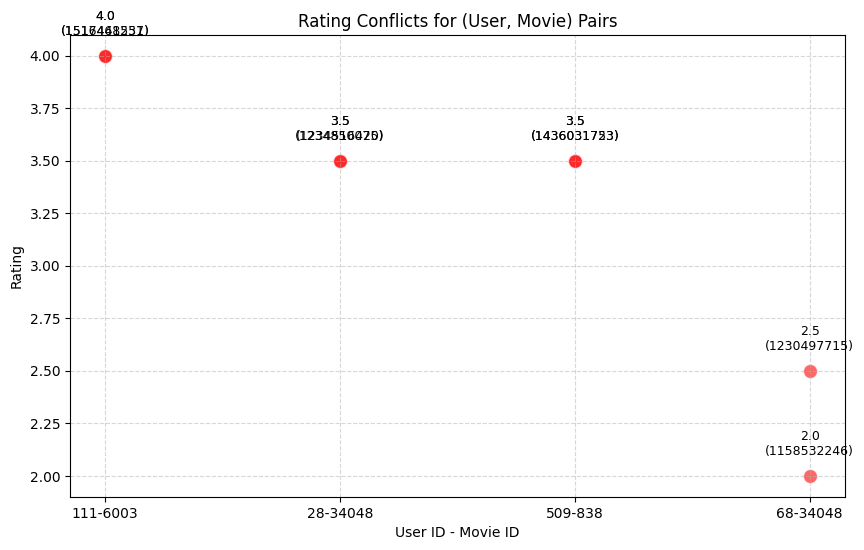

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 사용자 ID, 영화 ID 동일 충돌 데이터(User-Item 중복) 발굴
# keep=False : 중복된 모든 행을 다 가져옵니다 (원본 포함)
dup_mask = ratings_df.duplicated(subset=['user_id', 'movie_id'], keep=False)
conflict_df = ratings_df[dup_mask].sort_values(by=['user_id', 'movie_id'])

# 데이터가 있는지 확인
if conflict_df.empty:
    print("🎉 와우! 시각화할 충돌 데이터가 없습니다. (데이터가 이미 깔끔합니다)")
else:
    print(f"⚠️ 총 {len(conflict_df)}개의 충돌 평점 행이 발견되었습니다.")
    print(f"   (중복 평가를 한 유저 수: {conflict_df['user_id'].nunique()}명)")

    plt.figure(figsize=(10, 6))

    # x축: User-Item 조합 (구분을 위해 임의로 문자열 생성), y축: Rating
    conflict_df['user_item_label'] = conflict_df['user_id'].astype(str) + '-' + conflict_df['movie_id'].astype(str)

    # 산점도로 점수 분포 찍어보기
    sns.scatterplot(data=conflict_df, x='user_item_label', y='rating', s=100, color='red', alpha=0.6)

    # 텍스트로 구체적인 점수 표시
    for i in range(len(conflict_df)):
        row = conflict_df.iloc[i]
        plt.text(row['user_item_label'], row['rating']+0.1,
                 f"{row['rating']}\n({row['timestamp']})",
                 ha='center', fontsize=9)

    plt.title('Rating Conflicts for (User, Movie) Pairs')
    plt.xlabel('User ID - Movie ID')
    plt.ylabel('Rating')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

In [175]:
# 원본 보호를 위해 복사본 생성
ratings_original = ratings_df.copy()

# ---------------------------------------------------------
# 전략 A: 평균값 (Mean)으로 합치기
# ---------------------------------------------------------
ratings_mean = ratings_original.groupby(['user_id', 'movie_id'], as_index=False).agg({
    'rating': 'mean',       # 평점은 평균
    'timestamp': 'max'      # 타임스탬프는 그냥 최신꺼 남김 (큰 의미 없음)
})
print(f"Dataset A (Mean) Size: {len(ratings_mean)}")


# ---------------------------------------------------------
# 전략 B: 최신값 (Latest)으로 합치기
# ---------------------------------------------------------
# 1. timestamp 기준으로 정렬 (내림차순: 최신이 위로)
ratings_sorted = ratings_original.sort_values(by=['user_id', 'movie_id', 'timestamp'], ascending=[True, True, False])

# 2. user_id와 movie_id가 같은 것 중 맨 위에 있는 것(최신)만 남기고 중복 제거
ratings_latest = ratings_sorted.drop_duplicates(subset=['user_id', 'movie_id'], keep='first')

print(f"Dataset B (Latest) Size: {len(ratings_latest)}")

Dataset A (Mean) Size: 100832
Dataset B (Latest) Size: 100832


In [176]:
# ---------------------------------------------------------
# [User '68', Movie '34048'] 지정 검색
# ---------------------------------------------------------

# 1. 문자열(str) 형태로 정확하게 타겟 지정
target_user = '68'
target_movie = '34048'

print(f"\n--- [Target User: {target_user}, Target Movie: {target_movie}] 검증 ---")

# 2. 원본 충돌 데이터에서 해당 유저+영화 조합만 추출
# (아까처럼 영화만 검색하면 다른 유저가 섞여 나옵니다)
target_conflict = conflict_df[
    (conflict_df['user_id'] == target_user) &
    (conflict_df['movie_id'] == target_movie)
]

print("\n1. 원본 데이터 (이 유저의 충돌 내역):")
print(target_conflict[['rating', 'timestamp']])

# 3. 평균 처리값 확인
val_mean = ratings_mean[
    (ratings_mean['user_id'] == target_user) &
    (ratings_mean['movie_id'] == target_movie)
]
print(f"\n2. 평균 처리값 (기대값: 2.25): {val_mean['rating'].values[0]}")

# 4. 최신 처리값 확인
# 115... vs 123... 중 123...이 더 크므로(최신), 2.5점이 나와야 함
val_latest = ratings_latest[
    (ratings_latest['user_id'] == target_user) &
    (ratings_latest['movie_id'] == target_movie)
]
print(f"3. 최신 처리값 (기대값: 2.5): {val_latest['rating'].values[0]}")


--- [Target User: 68, Target Movie: 34048] 검증 ---

1. 원본 데이터 (이 유저의 충돌 내역):
       rating   timestamp
11241     2.0  1158532246
11451     2.5  1230497715

2. 평균 처리값 (기대값: 2.25): 2.25
3. 최신 처리값 (기대값: 2.5): 2.5


## 장르 결측치 처리

Imputation

In [177]:
# 컴퓨터는 "no genres listed"를 하나의 장르로 인식하는 오류를 범함.
no_genre_cond = movies_df['genres'].str.contains(' ')
movies_df[no_genre_cond]

,movie_id,title,genres
8517,114335,La cravate (1957),(no genres listed)
8684,122888,Ben-hur (2016),(no genres listed)
8687,122896,Pirates of the Caribbean: Dead Men Tell No Tal...,(no genres listed)
8782,129250,Superfast! (2015),(no genres listed)
8836,132084,Let It Be Me (1995),(no genres listed)
8902,134861,Trevor Noah: African American (2013),(no genres listed)
9033,141131,Guardians (2016),(no genres listed)
9053,141866,Green Room (2015),(no genres listed)
9070,142456,The Brand New Testament (2015),(no genres listed)
9091,143410,Hyena Road,(no genres listed)


원래 태그가 많으면 태그 기반으로 영화 장르 결측치를 채우려고 했었음.

In [178]:
# 1. 장르가 없는 영화들의 ID 목록 추출
target_mask = (movies_df['genres'] == '(no genres listed)') | (movies_df['genres'].str.strip() == '')
missing_ids = movies_df.loc[target_mask, 'movie_id'].values

print(f"1. 장르가 없는 영화 ID 예시 (3개): {missing_ids[:3]}")

# 2. 데이터 타입(Dtype) 검사 (이게 다르면 매칭 안됨)
type_movie = movies_df['movie_id'].dtype
type_tag = tags_df['movie_id'].dtype
print(f"2. ID 데이터 타입 확인 -> Movies: {type_movie} vs Tags: {type_tag}")

if str(type_movie) != str(type_tag):
    print("   🚨 [경고] 데이터 타입이 다릅니다! 이것 때문에 매칭이 0개 뜬 겁니다.")
else:
    print("   ✅ 데이터 타입은 일치합니다.")

# 3. 태그 데이터 존재 여부 확인
# 장르가 없는 영화 ID가 tags_df에 단 하나라도 있는지 확인
tags_for_missing = tags_df[tags_df['movie_id'].isin(missing_ids)]

print(f"3. 장르 미표기 영화(34개)에 달린 태그 개수: {len(tags_for_missing)}")

if not tags_for_missing.empty:
    print("\n   [발견된 태그 내용 미리보기]")
    print(tags_for_missing[['movie_id', 'tag']].head(10))
else:
    print("   ❌ [결론] 이 영화들은 너무 인기가 없어서 태그 데이터조차 없습니다.")
    print("   -> 복구 불가능합니다. 삭제(Drop)하는 것이 맞습니다.")

1. 장르가 없는 영화 ID 예시 (3개): ['114335' '122888' '122896']
2. ID 데이터 타입 확인 -> Movies: object vs Tags: object
   ✅ 데이터 타입은 일치합니다.
3. 장르 미표기 영화(34개)에 달린 태그 개수: 3

   [발견된 태그 내용 미리보기]
     movie_id          tag
3279   156605       quirky
3280   156605        sweet
3281   156605  understated


In [179]:
import pandas as pd

# 1. 전체 영화 중 태그가 있는 영화 비율 계산
total_movies_count = movies_df['movie_id'].nunique()
tagged_movies_count = tags_df['movie_id'].nunique()

print(f"🎥 전체 영화 수: {total_movies_count}개")
print(f"🏷️ 태그가 있는 영화 수: {tagged_movies_count}개")
print(f"📊 태그 보유 비율: {tagged_movies_count / total_movies_count * 100:.2f}%")
print("-" * 50)

# 2. 태그가 가장 많이 달린 인기 영화 Top 5 확인
# movie_id별로 태그 개수 세기
tag_counts = tags_df.groupby('movie_id').size().reset_index(name='tag_count')
# 내림차순 정렬
top_tagged = tag_counts.sort_values('tag_count', ascending=False).head(5)

# 영화 제목 정보를 붙여서 보기 좋게 출력
top_tagged_info = pd.merge(top_tagged, movies_df, on='movie_id', how='left')

print("\n🏆 태그가 가장 많은 영화 Top 5:")
for idx, row in top_tagged_info.iterrows():
    print(f"{idx+1}위: {row['title']} (ID: {row['movie_id']}) - 태그 {row['tag_count']}개")

print("-" * 50)

# 3. 실제 태그 내용 구경하기 (1위 영화의 태그 일부)
# 가장 태그가 많은 영화(1위)의 ID 가져오기
top_movie_id = top_tagged.iloc[0]['movie_id']
top_movie_title = top_tagged_info.iloc[0]['title']

print(f"\n👀 '{top_movie_title}' 영화에 달린 태그 예시 (10개만):")
sample_tags = tags_df[tags_df['movie_id'] == top_movie_id]['tag'].head(10).values
print(sample_tags)

🎥 전체 영화 수: 9737개
🏷️ 태그가 있는 영화 수: 1572개
📊 태그 보유 비율: 16.14%
--------------------------------------------------

🏆 태그가 가장 많은 영화 Top 5:
1위: Pulp Fiction (1994) (ID: 296) - 태그 181개
2위: Fight Club (1999) (ID: 2959) - 태그 54개
3위: 2001: A Space Odyssey (1968) (ID: 924) - 태그 41개
4위: Léon: The Professional (a.k.a. The Professional) (Léon) (1994) (ID: 293) - 태그 35개
5위: Eternal Sunshine of the Spotless Mind (2004) (ID: 7361) - 태그 34개
--------------------------------------------------

👀 'Pulp Fiction (1994)' 영화에 달린 태그 예시 (10개만):
['good dialogue' 'great soundtrack' 'non-linear' 'cult film' 'drugs'
 'Quentin Tarantino' 'Tarantino' 'hit men' '1990s' 'achronological']


In [180]:
len(movies_df[no_genre_cond])

34

In [181]:
len(movies_df[~no_genre_cond])

9703

이 장르가 없는 34개의 영화는 인기가 없으심.
현재 장르 미상 영화의 평균 평점 개수는 1.4개로 이 데이터는 어차피 협업 필터링 계산에서 유사도 0에 수렴하여 추천될 확률이 없기에 삭제할 예정

In [182]:
# 장르 없는 영화들의 ID 리스트
missing_ids = movies_df.loc[no_genre_cond, 'movie_id'].tolist()

# 이 영화들에 달린 평점 개수 세기
ratings_count = ratings_df[ratings_df['movie_id'].isin(missing_ids)]['movie_id'].value_counts()

print(f"장르 미상 영화(34개)의 평균 평점 개수: {ratings_count.mean():.1f}개")
print(f"최대 평점 개수: {ratings_count.max()}개")
print(ratings_count)

장르 미상 영화(34개)의 평균 평점 개수: 1.4개
최대 평점 개수: 7개
movie_id
122896    7
141866    3
166024    2
172591    2
171495    2
142456    2
152037    2
114335    1
147250    1
174403    1
134861    1
173535    1
171631    1
159161    1
171891    1
171749    1
176601    1
155589    1
169034    1
159779    1
181413    1
167570    1
129250    1
143410    1
149330    1
172497    1
182727    1
165489    1
122888    1
156605    1
141131    1
181719    1
132084    1
161008    1
Name: count, dtype: int64


In [183]:
# 장르 없으면 사용안할 것
del_movie_ids = movies_df.loc[no_genre_cond, 'movie_id'].tolist()
len(del_movie_ids)

34

In [184]:
movies_df = movies_df[~movies_df['movie_id'].isin(del_movie_ids)].copy()
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [185]:
# 검산: 삭제 id 데이터는 없어야 한
movies_df[no_genre_cond]

/tmp/ipython-input-1277428978.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  movies_df[no_genre_cond]


,movie_id,title,genres


ratings 데이터도 처리 필요

In [186]:
# 결측치 확인을 꼭 해줘야함~ null 값이 있는지 check!
len(ratings_df)

100836

In [187]:
# 삭제할 영화 관련 데이터
len(ratings_df[ratings_df['movie_id'].isin(del_movie_ids)])

47

In [188]:
100836 - 47  # 삭제 후 데이터 개수

100789

In [189]:
ratings_df = ratings_df[~ratings_df['movie_id'].isin(del_movie_ids)].copy()
ratings_df

,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


## 그외 결측치 체크

In [190]:
movies_df.columns[movies_df.isna().any()].tolist()

[]

## 인덱스 정리

In [191]:
# 중복 제거 작업으로 인덱스 불일치 상태
# 행은 삭제했는데 인덱스는 유지되는 경우인지 확인해야함! (인덱스 miss match)
# 지금도 행이 9703개라고 뜨는데, 인덱스는 9741개나 있음! -> 굉장히 위험한 일~
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [192]:
# 특히 delete하는 과정 이후에는 reset_index하는 거 꼭꼭 기억해~ (이거 했다는 거 발표해라!!!!!!!!)
# 만약 pandas가 아닌 다른 인덱스가 없는 라이브러리를 사용했다면 괜찮을 수도 있음.
movies_df = movies_df.reset_index(drop=True)
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9698,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9699,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9700,193585,Flint (2017),Drama
9701,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [193]:
# 중복 제거 작업으로 인덱스 불일치 상태
ratings_df

,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [194]:
ratings_df = ratings_df.reset_index(drop=True)
ratings_df

,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100784,610,166534,4.0,1493848402
100785,610,168248,5.0,1493850091
100786,610,168250,5.0,1494273047
100787,610,168252,5.0,1493846352


## 구분자 변경

TfidfVectorizer 사용하려면 space 를 seperator 로 써야

In [195]:
# 장르 이름에는 빈칸 없다
# 만약 빈칸 있으면 _ 붙이는 처리 필요
# 예) k drama|fun --> k drama fun  (X)
#                 --> k_drama fun  (O)
movies_df[movies_df['genres'].str.contains(' ')]

,movie_id,title,genres


In [196]:
movies_df['genres']

,genres
0,Adventure|Animation|Children|Comedy|Fantasy
1,Adventure|Children|Fantasy
2,Comedy|Romance
3,Comedy|Drama|Romance
4,Comedy
...,...
9698,Action|Animation|Comedy|Fantasy
9699,Animation|Comedy|Fantasy
9700,Drama
9701,Action|Animation


In [197]:
# 장르를 파이프라인 대신 빈칸으로 구분지음.
movies_df['genres'].str.replace('\|',' ', regex=True)

<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipython-input-2535087697.py:2: SyntaxWarning: invalid escape sequence '\|'
  movies_df['genres'].str.replace('\|',' ', regex=True)


,genres
0,Adventure Animation Children Comedy Fantasy
1,Adventure Children Fantasy
2,Comedy Romance
3,Comedy Drama Romance
4,Comedy
...,...
9698,Action Animation Comedy Fantasy
9699,Animation Comedy Fantasy
9700,Drama
9701,Action Animation


In [198]:
movies_df['genres'] = movies_df['genres'].str.replace(r'\|',' ', regex=True)
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9698,193581,Black Butler: Book of the Atlantic (2017),Action Animation Comedy Fantasy
9699,193583,No Game No Life: Zero (2017),Animation Comedy Fantasy
9700,193585,Flint (2017),Drama
9701,193587,Bungo Stray Dogs: Dead Apple (2018),Action Animation


## 연도 결측치 처리

In [199]:
# 제목에 연도 없는 데이터 검색 (다른 영화는 영화 제목 뒤에 연도가 있음.)
# 예를 들어 리메이크 영화인 경우 이름은 같고 연도가 다른 경우가 있을 수도 있는데 연도를 삭제해버리면 안 되겠죠~
# 정답은 없음. 우리는 이런 이유로 연도 컬러를 따로 뺐으며, 구분을 위해 제목에서 이렇게 했다~ 뭐 이렇게 하라는디
# movies_df[~movies_df['title'].str.contains('(')]  <-- \( 사용해야함
movies_df[~movies_df['title'].str.contains(r'\(')]

,movie_id,title,genres
6058,40697,Babylon 5,Sci-Fi
9023,140956,Ready Player One,Action Sci-Fi Thriller
9163,149334,Nocturnal Animals,Drama Thriller
9345,162414,Moonlight,Drama


In [200]:
# 정규표현식 사용: \(는 실제 괄호를 의미합니다.
# regex=True를 명시하는 것이 권장됩니다.
no_year_movies = movies_df[~movies_df['title'].str.contains(r'\(\d{4}\)', regex=True)]

print(f"연도 정보가 없는 영화 수: {len(no_year_movies)}")
print(no_year_movies.head())

연도 정보가 없는 영화 수: 4
     movie_id              title                  genres
6058    40697          Babylon 5                  Sci-Fi
9023   140956   Ready Player One  Action Sci-Fi Thriller
9163   149334  Nocturnal Animals          Drama Thriller
9345   162414          Moonlight                   Drama


웹 검색으로 영화 연도 찾은 결과
```
'Babylon 5': 1994
'Ready Player One': 2018
'Nocturnal Animals': 2017
'Moonlight': 2009
```

In [201]:
tmp = movies_df.copy()

In [202]:
tmp.loc[6058, 'title'] = tmp.loc[6058, 'title'] + " (1994)"
tmp.loc[[6058]]

,movie_id,title,genres
6058,40697,Babylon 5 (1994),Sci-Fi


In [203]:
# 중복 실행 시 연도 중첩 방지 필요
tmp.loc[6058, 'title'] = tmp.loc[6058, 'title'] + " (1994)"
tmp.loc[[6058]]

,movie_id,title,genres
6058,40697,Babylon 5 (1994) (1994),Sci-Fi


In [204]:
# 연도 없는지 체크
'(' not in tmp.loc[6058, 'title']

False

In [205]:
tmp = movies_df.copy()
idx = 6058
year = 1994

if '(' not in tmp.loc[idx, 'title']:
    tmp.loc[idx, 'title'] = tmp.loc[idx, 'title'] + f" ({year})"

tmp.loc[[idx]]

,movie_id,title,genres
6058,40697,Babylon 5 (1994),Sci-Fi


In [206]:
# 직접 입력
idx = 6058
year = 1994
if '(' not in movies_df.loc[idx, 'title']:
    movies_df.loc[idx, 'title'] = movies_df.loc[idx, 'title'] + f" ({year})"
movies_df.loc[[idx]]

,movie_id,title,genres
6058,40697,Babylon 5 (1994),Sci-Fi


In [207]:
# 직접 입력
idx = 9023
year = 2018
if '(' not in movies_df.loc[idx, 'title']:
    movies_df.loc[idx, 'title'] = movies_df.loc[idx, 'title'] + f" ({year})"
movies_df.loc[[idx]]

,movie_id,title,genres
9023,140956,Ready Player One (2018),Action Sci-Fi Thriller


In [208]:
# 직접 입력
idx = 9163
year = 2017
if '(' not in movies_df.loc[idx, 'title']:
    movies_df.loc[idx, 'title'] = movies_df.loc[idx, 'title'] + f" ({year})"
movies_df.loc[[idx]]

,movie_id,title,genres
9163,149334,Nocturnal Animals (2017),Drama Thriller


In [209]:
# 직접 입력
idx = 9345
year = 2009
if '(' not in movies_df.loc[idx, 'title']:
    movies_df.loc[idx, 'title'] = movies_df.loc[idx, 'title'] + f" ({year})"
movies_df.loc[[idx]]

,movie_id,title,genres
9345,162414,Moonlight (2009),Drama


In [210]:
# 검산: 제목에 연도 없는 데이터 검색
movies_df[~movies_df['title'].str.contains(r'\(')]

,movie_id,title,genres


In [211]:
import pandas as pd

# 1. 검증을 위한 임시 컬럼 생성 (순수 제목 추출)
# 정규표현식으로 뒤에 붙은 (1995) 같은 연도 부분을 제거하고 공백을 없앱니다.
# 예: "Emma (1996)" -> "Emma"
movies_df['title_clean'] = movies_df['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

# 2. 'title_clean'이 중복된 영화 찾기 (keep=False: 중복된 모든 행을 다 보여줌)
# 같은 제목이 2개 이상 있는 경우만 필터링
duplicate_mask = movies_df.duplicated(subset=['title_clean'], keep=False)
duplicates_df = movies_df[duplicate_mask].sort_values(by=['title_clean', 'title'])

# 3. 결과 출력
if duplicates_df.empty:
    print("✅ 동명 영화가 없습니다. (데이터셋이 아주 유니크하네요!)")
else:
    print(f"⚠️ 제목은 같지만 서로 다른 영화가 총 {len(duplicates_df)}개 발견되었습니다.")
    print(f"   (중복된 제목의 종류: {duplicates_df['title_clean'].nunique()}개)")
    print("\n[동명 영화 예시 - 리메이크작 등]")

    # 보기 좋게 상위 10개만 출력 (필요한 컬럼만)
    # genres까지 같이 보면 더 확실하게 구분됩니다.
    print(duplicates_df[['movie_id', 'title', 'genres']].head(10))

⚠️ 제목은 같지만 서로 다른 영화가 총 525개 발견되었습니다.
   (중복된 제목의 종류: 250개)

[동명 영화 예시 - 리메이크작 등]
     movie_id                                title  \
905      1203                  12 Angry Men (1957)   
7330    77846                  12 Angry Men (1997)   
9042   141844                     12 Chairs (1971)   
9037   141816                     12 Chairs (1976)   
6862    62383  20,000 Leagues Under the Sea (1916)   
777      1019  20,000 Leagues Under the Sea (1954)   
3791     5300                  3:10 to Yuma (1957)   
6556    54997                  3:10 to Yuma (2007)   
3116     4191                         Alfie (1966)   
5364     8948                         Alfie (2004)   

                                       genres  
905                                     Drama  
7330                              Crime Drama  
9042                         Adventure Comedy  
9037                         Adventure Comedy  
6862                  Action Adventure Sci-Fi  
777                    Adventure Dra

영화 데이터 중에는 제목은 같지만 개봉 연도가 다른 리메이크작이나 동명 이인 영화가 존재함.  
정규표현식을 활용하여 제목 문자열 끝에 붙은 연도 정보를 추출해 별도의 year 컬럼으로 독립시킴.  
연도 정보가 누락된 데이터를 0 또는 unknown으로 처리하여 결측치 방어.  

In [212]:
import pandas as pd

def extract_year_from_title(movies_df):
    # 1. 정규표현식으로 '괄호 안의 숫자 4개'를 추출하여 'year' 컬럼 생성
    # expand=False: 시리즈 형태로 반환
    movies_df['year'] = movies_df['title'].str.extract(r'\((\d{4})\)', expand=False)

    # 2. 연도 추출에 실패한(NaN) 경우 '0' 또는 'Unknown'으로 채우기 (선택사항)
    movies_df['year'] = movies_df['year'].fillna('0')

    # 3. title 컬럼에서 연도 부분 삭제 (선택사항: 깔끔하게 보고 싶다면)
    # 예: "Toy Story (1995)" -> "Toy Story"
    # strip()으로 앞뒤 공백 제거
    movies_df['title'] = movies_df['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

    return movies_df

# 함수 실행
movies_df = extract_year_from_title(movies_df)

# 결과 확인
print(movies_df[['title', 'year']].head())

                         title  year
0                    Toy Story  1995
1                      Jumanji  1995
2             Grumpier Old Men  1995
3            Waiting to Exhale  1995
4  Father of the Bride Part II  1995


## 영화명/연도 분리

### 연습

In [213]:
"Waiting to Exhale (1995)".rsplit(' ', 1)

['Waiting to Exhale', '(1995)']

In [214]:
# 여백 주의! split에 영향줌
"Waiting to Exhale (1995) ".rsplit(' ', 1)

['Waiting to Exhale (1995)', '']

In [215]:
"Waiting to Exhale (1995) ".strip()

'Waiting to Exhale (1995)'

In [216]:
"Waiting to Exhale (1995) ".strip().rsplit(' ', 1)

['Waiting to Exhale', '(1995)']

In [217]:
movies_df['title'].str.rsplit(' ', n=1)

,title
0,"[Toy, Story]"
1,[Jumanji]
2,"[Grumpier Old, Men]"
3,"[Waiting to, Exhale]"
4,"[Father of the Bride Part, II]"
...,...
9698,"[Black Butler: Book of the, Atlantic]"
9699,"[No Game No Life:, Zero]"
9700,[Flint]
9701,"[Bungo Stray Dogs: Dead, Apple]"


In [218]:
movies_df['title'].str.rsplit(' ', n=1, expand=True)

,0,1
0,Toy,Story
1,Jumanji,None
2,Grumpier Old,Men
3,Waiting to,Exhale
4,Father of the Bride Part,II
...,...,...
9698,Black Butler: Book of the,Atlantic
9699,No Game No Life:,Zero
9700,Flint,None
9701,Bungo Stray Dogs: Dead,Apple


### 적용

In [219]:
# movies_df['title'] = movies_df['title'].str.strip()
# movies_df

In [220]:
# movies_df[['title_only', 'year']] = movies_df['title'].str.rsplit(' ', n=1, expand=True)
# movies_df

In [221]:
# # 연도에 괄호 제거하고 int 타입 변환
# movies_df['year'] = movies_df['year'].apply(lambda x: x[1:-1])
# movies_df['year'] = movies_df['year'].astype(int)
# movies_df

In [222]:
# # 영화명 같이만 개봉 연도 다른 리메이크작 존재함
# # title_only 보다 title 그대로 사용
# movies_df = movies_df[['movie_id', 'title', 'year', 'genres']]
# movies_df

# 데이터 저장

In [230]:
import os

# 1. 저장할 폴더가 없으면 만들기 (안전장치)
# DATA_DIR이 pathlib 객체라고 가정합니다.
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

# 2. Movies 저장
movie_file_path = DATA_DIR / "movies_refined.csv"
movies_df.to_csv(movie_file_path, index=False)
print(f"✅ Movies 저장 완료: {movie_file_path} ({len(movies_df)} rows)")

# 3. Ratings 저장
ratings_file_path = DATA_DIR / "ratings_refined.csv"
ratings_df.to_csv(ratings_file_path, index=False)
print(f"✅ Ratings 저장 완료: {ratings_file_path} ({len(ratings_df)} rows)")

# 4. Tags 저장 (중요! ID 싱크가 맞춰진 데이터)
tags_file_path = DATA_DIR / "tags_refined.csv"
tags_df.to_csv(tags_file_path, index=False)
print(f"✅ Tags 저장 완료: {tags_file_path} ({len(tags_df)} rows)")

✅ Movies 저장 완료: /content/drive/MyDrive/Colab Notebooks/data/movies_refined.csv (9703 rows)
✅ Ratings 저장 완료: /content/drive/MyDrive/Colab Notebooks/data/ratings_refined.csv (100789 rows)
✅ Tags 저장 완료: /content/drive/MyDrive/Colab Notebooks/data/tags_refined.csv (3683 rows)


In [223]:
# movie_file_path = DATA_DIR / "movies_refined.csv"
# movie_file_path

PosixPath('/content/drive/MyDrive/Colab Notebooks/data/movies_refined.csv')

In [224]:
# movies_df.to_csv(movie_file_path, index=False)
# movies_df

,movie_id,title,genres,title_clean,year
0,1,Toy Story,Adventure Animation Children Comedy Fantasy,Toy Story,1995
1,2,Jumanji,Adventure Children Fantasy,Jumanji,1995
2,3,Grumpier Old Men,Comedy Romance,Grumpier Old Men,1995
3,4,Waiting to Exhale,Comedy Drama Romance,Waiting to Exhale,1995
4,5,Father of the Bride Part II,Comedy,Father of the Bride Part II,1995
...,...,...,...,...,...
9698,193581,Black Butler: Book of the Atlantic,Action Animation Comedy Fantasy,Black Butler: Book of the Atlantic,2017
9699,193583,No Game No Life: Zero,Animation Comedy Fantasy,No Game No Life: Zero,2017
9700,193585,Flint,Drama,Flint,2017
9701,193587,Bungo Stray Dogs: Dead Apple,Action Animation,Bungo Stray Dogs: Dead Apple,2018


In [225]:
# ratings_file_path = DATA_DIR / "ratings_refined.csv"
# ratings_file_path

PosixPath('/content/drive/MyDrive/Colab Notebooks/data/ratings_refined.csv')

In [226]:
# ratings_df.to_csv(ratings_file_path, index=False)
# ratings_df

,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100784,610,166534,4.0,1493848402
100785,610,168248,5.0,1493850091
100786,610,168250,5.0,1494273047
100787,610,168252,5.0,1493846352


# 참고

Timstamp -> Datetime

In [227]:
from datetime import datetime
datetime.fromtimestamp(964982703)

datetime.datetime(2000, 7, 30, 18, 45, 3)

In [228]:
time_unit = 2
datetime.fromtimestamp(964982703 / time_unit)

datetime.datetime(1985, 4, 16, 9, 22, 31, 500000)

In [229]:
from datetime import datetime
tmp = ratings_df.copy()
time_unit = 2
tmp['datetime'] = tmp['timestamp'].apply(lambda x: datetime.fromtimestamp(x/time_unit))
tmp

,user_id,movie_id,rating,timestamp,datetime
0,1,1,4.0,964982703,1985-04-16 09:22:31.500
1,1,3,4.0,964981247,1985-04-16 09:10:23.500
2,1,6,4.0,964982224,1985-04-16 09:18:32.000
3,1,47,5.0,964983815,1985-04-16 09:31:47.500
4,1,50,5.0,964982931,1985-04-16 09:24:25.500
...,...,...,...,...,...
100784,610,166534,4.0,1493848402,1993-09-01 22:56:41.000
100785,610,168248,5.0,1493850091,1993-09-01 23:10:45.500
100786,610,168250,5.0,1494273047,1993-09-04 09:55:23.500
100787,610,168252,5.0,1493846352,1993-09-01 22:39:36.000
